# 05 — Weak lensing: galaxy ellipticities

Two estimators of `(e1, e2)` from a galaxy image:

1. **Parametric**: forward-fit Sérsic + PSF (gold standard).
2. **Quadrupole moments** (KSB-style): non-parametric baseline.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


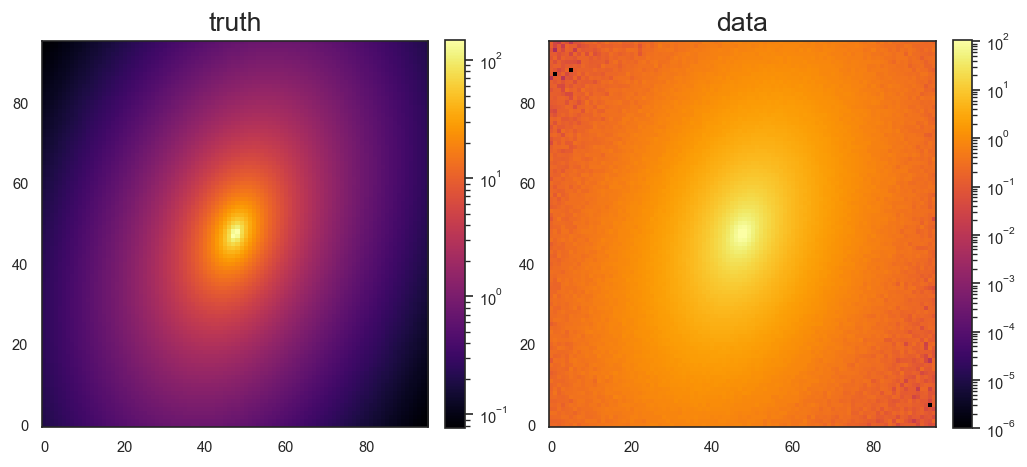

In [2]:
npix, dx = 96, 0.05
xy = gl.data.coordinate_grid(npix=npix, deltapix=dx)

true = dict(Ie=5.0, Re=0.8, n=2.5, x0=0., y0=0., e1=-0.20, e2=0.15)
galaxy = gl.light.Sersic(**true)

sigma_n = 0.05
clean, image = gl.data.simulate_image(
    galaxy, xy, psf_fwhm=0.10, deltapix=dx, psf_size=21,
    noise_sigma=sigma_n, seed=3,
)
gl.viz.side_by_side([clean, image], titles=['truth', 'data'], log=True)
plt.show()


## 1. Parametric estimator (Sérsic + PSF)

In [3]:
result, summary = gl.inference.fit_ellipticity(
    image, xy, psf_fwhm=0.10, deltapix=dx, sigma=sigma_n,
    init=dict(Ie=1., Re=1., n=3., x0=0., y0=0., e1=0., e2=0.),
    epochs=3000,
)
print('parametric fit:')
for k, v in summary.items(): print(f"  {k:<8s}: {v:+.4f}")


parametric fit:
  Ie      : +4.9896
  Re      : +0.8011
  n       : +2.5019
  x0      : -0.0000
  y0      : -0.0000
  e1      : -0.1999
  e2      : +0.1500
  q       : +0.6001
  pa_rad  : +1.2490
  pa_deg  : +71.5629
  |e|     : +0.2499


## 2. Quadrupole-moment estimator

In [4]:
ks = gl.inference.kaiser_squires_estimator(image, xy, weight_sigma=1.0)
print('quadrupole estimator:')
for k, v in ks.items(): print(f"  {k:<8s}: {v:+.4f}")
print(f"\ntrue:  e1 = {true['e1']:+.4f}   e2 = {true['e2']:+.4f}")
print(f"|e|_true = {np.hypot(true['e1'], true['e2']):.4f}")


quadrupole estimator:
  x0      : -0.0001
  y0      : +0.0002
  e1      : -0.1050
  e2      : +0.0808
  |e|     : +0.1325
  q       : +0.7660
  pa_rad  : +1.2428
  pa_deg  : +71.2085

true:  e1 = -0.2000   e2 = +0.1500
|e|_true = 0.2500
